# Imports

In [7]:
from nb_utils import set_root
PROJECT_DIR = set_root(1)

In [8]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from typing import Any

# Methods

In [ ]:
def gerar_imagem(data, fator_largura=20, figsize=(16, 5), orient: str="horizontal") -> tuple:
    altura = 50
    
    if isinstance(data, dict):
        if orient == "horizontal":
            fig, axs = plt.subplots(1, len(data), figsize=figsize)
            plt.subplots_adjust(wspace=0.5)  # Ajustar o espaçamento entre os subplots
        elif orient == "vertical":
            fig, axs = plt.subplots(len(data), 1, figsize=figsize)
            plt.subplots_adjust(hspace=0.5)  # Ajustar o espaçamento entre os subplots
        
        if not isinstance(axs, np.ndarray):
            axs = np.array([axs])
        for _ax, (key, content) in zip(axs.flatten(), data.items()):
            if content["vetor"].ndim == 1:
                imagem_array = np.repeat(content["vetor"], fator_largura).reshape(1, -1)
                imagem_array = np.tile(imagem_array, (altura, 1))
            else:
                imagem_array = content["vetor"]
            imagem = Image.fromarray(imagem_array.astype(np.uint8), mode='L')
        
            _ax.imshow(imagem, cmap="gray", aspect="auto")
            _ax.axis("off")  # Remover eixos
            _ax.set_title(content["desc"])
    else:
        fig, ax = plt.subplots(figsize=figsize)
        imagem = Image.fromarray(data.astype(np.uint8), mode='L')
        ax.imshow(imagem, cmap="gray", aspect="auto")
        ax.axis("off")  # Remover eixos
    
    plt.show()
    return fig, axs if isinstance(data, dict) else (fig, ax)

In [10]:
def gerar_imagem_rgb(R: np.ndarray, G: np.ndarray, B: np.ndarray, figsize: tuple[int, int]):
    rgb_array = np.stack((R, G, B), axis=-1)
    imagem = Image.fromarray(rgb_array.astype(np.uint8), mode='RGB')
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(imagem)
    ax.axis("off")
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)  # Ajustar os parâmetros de layout
    return fig, ax

In [46]:
def find_closest_palette_color(value):
    """
    Finds the closest palette color for a given pixel value.
    For 1-bit black-and-white, it rounds to 0 or 255.
    """
    return 0 if value < 127 else 255

def floyd_steinberg_dithering(image):
    """
    Applies the Floyd-Steinberg dithering algorithm to a grayscale image.

    :param image: A numpy array representing the grayscale image.
    :return: A numpy array representing the binarized image.
    """
    # Convert the image to float to avoid overflow during error propagation
    pixels = image.astype(float)
    height, width = pixels.shape

    for y in range(height):
        for x in range(width):
            oldpixel = pixels[y, x]
            newpixel = find_closest_palette_color(oldpixel)
            pixels[y, x] = newpixel
            print(f"old_pixel: {oldpixel}")
            quant_error = oldpixel - newpixel
            print(f"-- P({y}, {x})")
            # Propagate the quantization error to neighboring pixels
            if x + 1 < width:
                txt = f"------------- P({y}, {x + 1}) = {pixels[y, x + 1]}+ {quant_error} * 7/16 = "
                pixels[y, x + 1] += quant_error * 7 / 16
                txt += str(pixels[y, x + 1])
                print(f"------------- {txt}")
            if x - 1 >= 0 and y + 1 < height:
                txt = f"------------- P({y + 1}, {x - 1}) = {pixels[y + 1, x - 1]} + {quant_error} * 3/16 = "
                pixels[y + 1, x - 1] += quant_error * 3 / 16
                txt += str(pixels[y + 1, x - 1])
                print(f"------------- {txt}")
            if y + 1 < height:
                txt = f"------------- P({y + 1}, {x}) = {pixels[y + 1, x]} + {quant_error} * 5/16 = "
                pixels[y + 1, x] += quant_error * 5 / 16
                txt += str(pixels[y + 1, x])
                print(f"------------- {txt}")
            if x + 1 < width and y + 1 < height:
                txt = f"------------- P({y + 1}, {x + 1}) = {pixels[y + 1, x + 1]} + {quant_error} * 1/16 = "
                pixels[y + 1, x + 1] += quant_error * 1 / 16
                txt += str(pixels[y + 1, x + 1])
                print(f"------------- {txt}")
            print(f"-- result: \n {pixels}")
            print()
        print()
        print()
    # Clip the values to ensure they remain within the valid range [0, 255]
    return np.clip(pixels, 0, 255).astype(np.uint8)


# Questão 04

In [11]:
contents: dict[str, Any] = {
    "orig": {
        "vetor": np.array([10, 20, 10, 50, 40, 40, 20, 20, 10, 10]),
        "desc": "Vetor original"
    },
    "equa": {
        "vetor": np.array([102, 179, 102, 255, 230, 230, 179, 179, 102, 102]),
        "desc": "Vetor equalizado"
    }
}

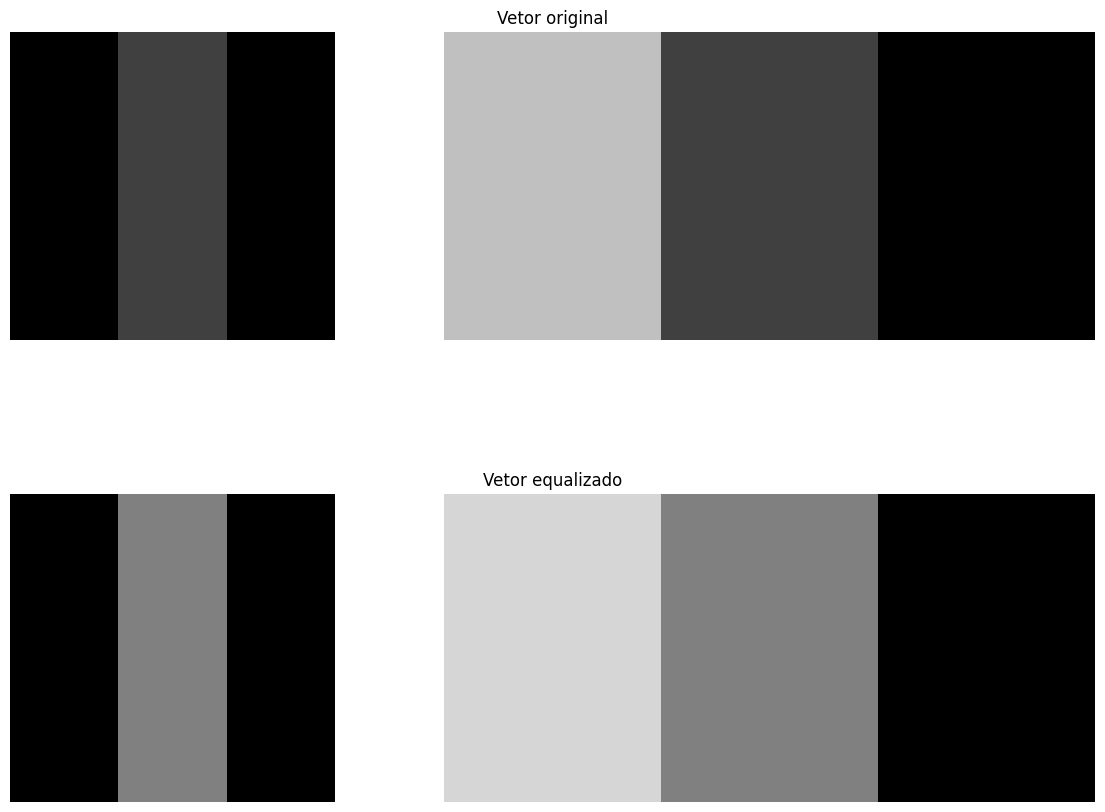

In [12]:
fig1, ax1 = gerar_imagem(
    contents,
    figsize=(14, 10),
    orient="vertical"
)
fig1.tight_layout()
fig1.savefig(PROJECT_DIR / "assets" / "atv04-q04.png", dpi=400)

# Questão 05

## Item a)

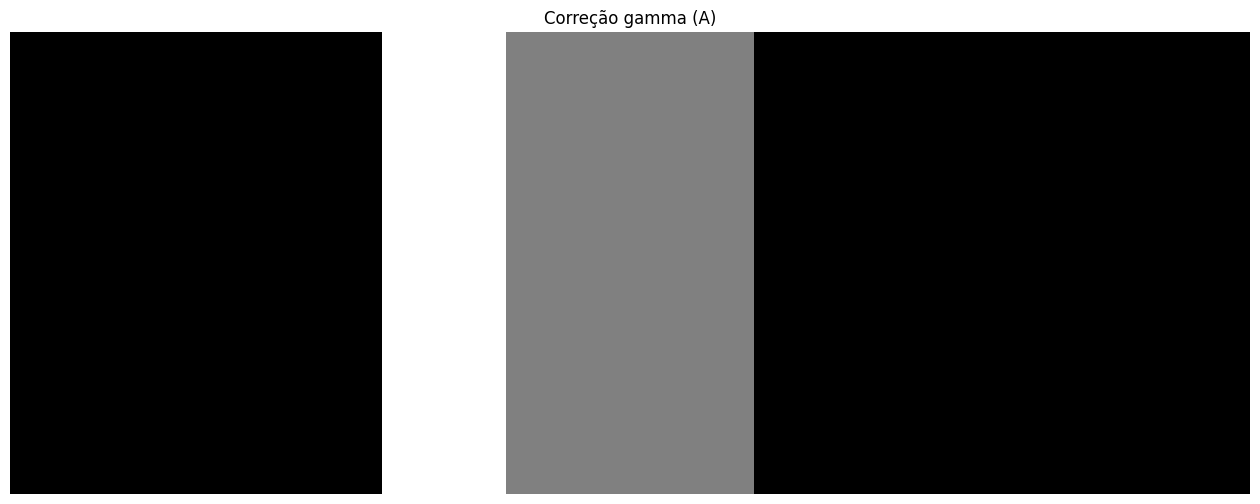

In [13]:
fig2, ax2 = gerar_imagem(
    {
        "gamma1": {
            "vetor": np.array([0, 0, 0, 2, 1, 1, 0, 0, 0, 0]),
            "desc": "Correção gamma (A)"
        }
    },
    figsize=(16, 6),
    orient="vertical"
)
fig2.tight_layout()
fig2.savefig(PROJECT_DIR / "assets" / "atv04-q05-01.png", dpi=400)

## Item b)

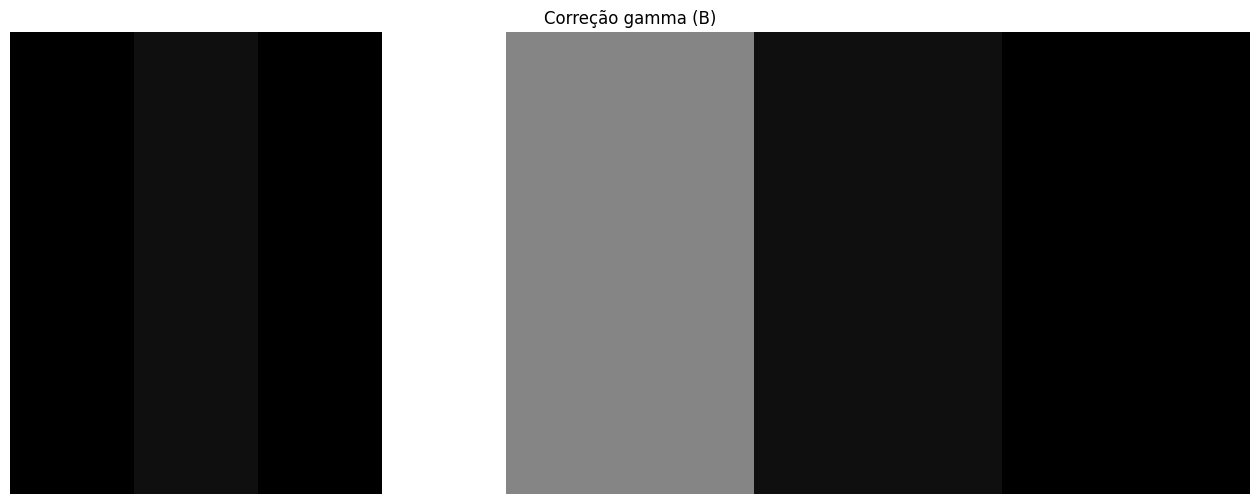

In [14]:
fig3, ax3 = gerar_imagem(
    {
        "gamma1": {
            "vetor": np.array([0, 3, 0, 50, 26, 26, 3, 3, 0, 0]),
            "desc": "Correção gamma (B)"
        }
    },
    figsize=(16, 6),
    orient="vertical"
)
fig3.tight_layout()
fig3.savefig(PROJECT_DIR / "assets" / "atv04-q05-02.png", dpi=400)

## Comparando resultados de ambos:

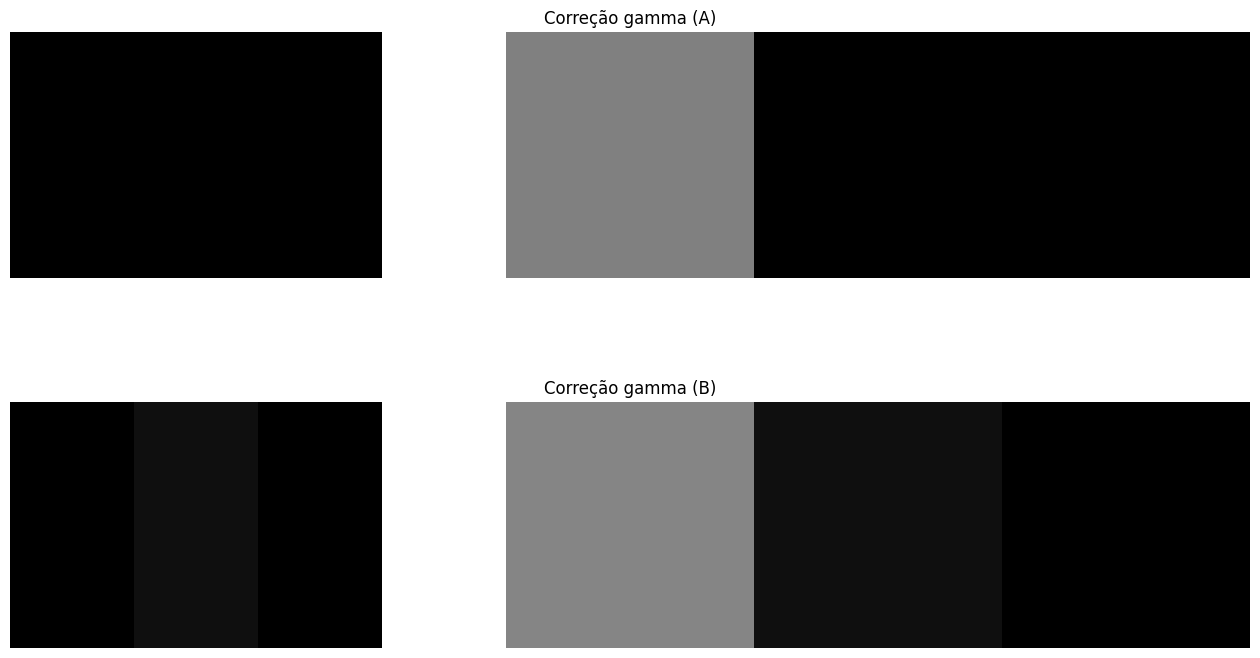

In [15]:
fig4, ax4 = gerar_imagem(
    {
        "gamma1": {
            "vetor": np.array([0, 0, 0, 2, 1, 1, 0, 0, 0, 0]),
            "desc": "Correção gamma (A)"
        },
        "gamma2": {
            "vetor": np.array([0, 3, 0, 50, 26, 26, 3, 3, 0, 0]),
            "desc": "Correção gamma (B)"
        }
    },
    figsize=(16, 8),
    orient="vertical"
)
fig4.tight_layout()
fig4.savefig(PROJECT_DIR / "assets" / "atv04-q05-03.png", dpi=400)

# Questão 06

In [16]:
R = np.array(
    [
        [255, 240, 200, 150, 120],
        [230, 220, 180, 160, 100],
        [210, 190, 170, 145, 90],
        [170, 160, 140, 130, 80],
        [185, 165, 155, 135, 122]
    ]
)

G = np.array(
    [
        [255, 240, 230, 235, 210],
        [240, 245, 250, 255, 180],
        [230, 220, 0, 230, 200],
        [240, 245, 250, 255, 180],
        [255, 240, 230, 235, 210]
    ]
)

B = np.array(
    [
        [255, 255, 200, 180, 160],
        [240, 230, 190, 140, 120],
        [245, 235, 0, 180, 160],
        [240, 230, 190, 140, 120],
        [255, 255, 200, 180, 160]
    ]
)

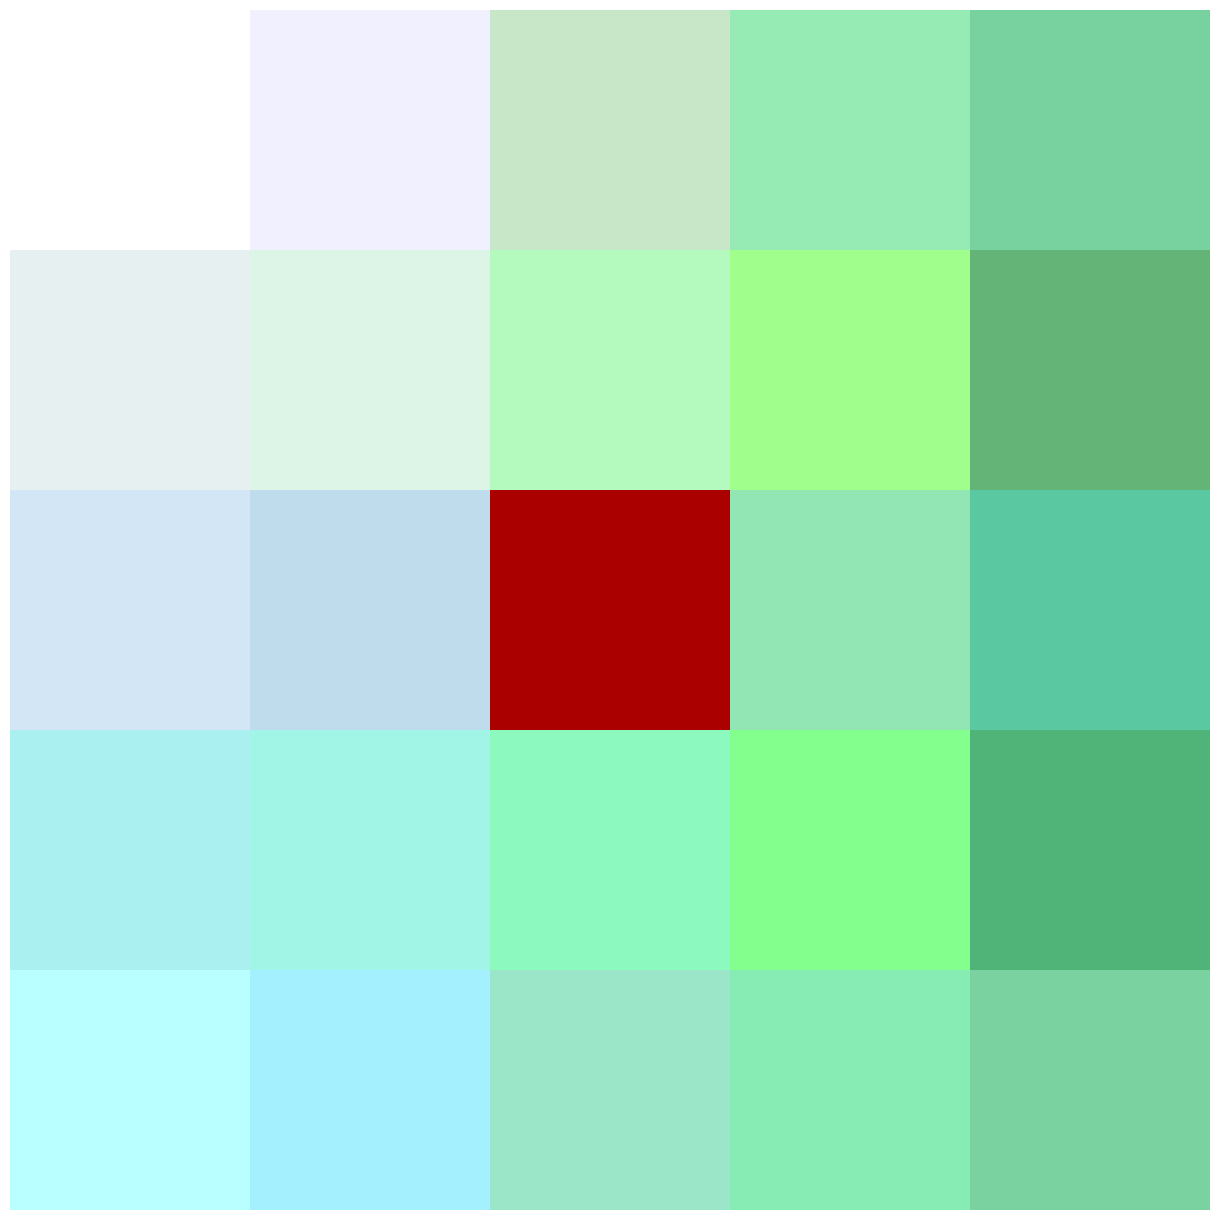

In [17]:
fig5, ax5 = gerar_imagem_rgb(R, G, B, figsize=(12, 12))
fig5.savefig(PROJECT_DIR / "assets" / "atv04-q06-01.png", dpi=400)

## Item A)

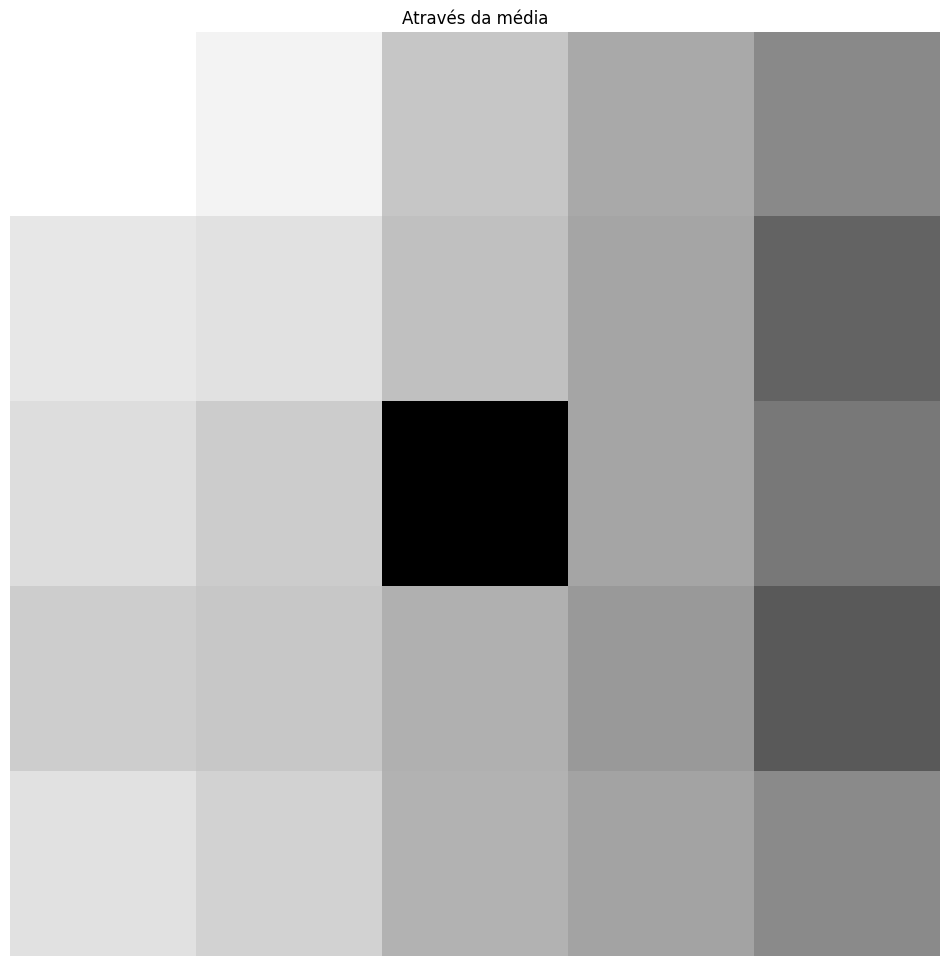

In [18]:
fig5, ax5 = gerar_imagem(
    {"media": {"desc": "Através da média", "vetor": (R + G + B) / 3}},
    figsize=(12, 12)
)
fig5.savefig(PROJECT_DIR / "assets" / "atv04-q06-02.png", dpi=400)

# Item B)

In [28]:
(0.29 * R).round() + ((0.59) * (G)).round() + (0.11 * B).round()
# (0.11) * (B)

array([[252., 240., 216., 203., 177.],
       [235., 234., 221., 211., 148.],
       [224., 211.,  49., 198., 162.],
       [217., 216., 210., 203., 142.],
       [232., 218., 203., 198., 177.]])

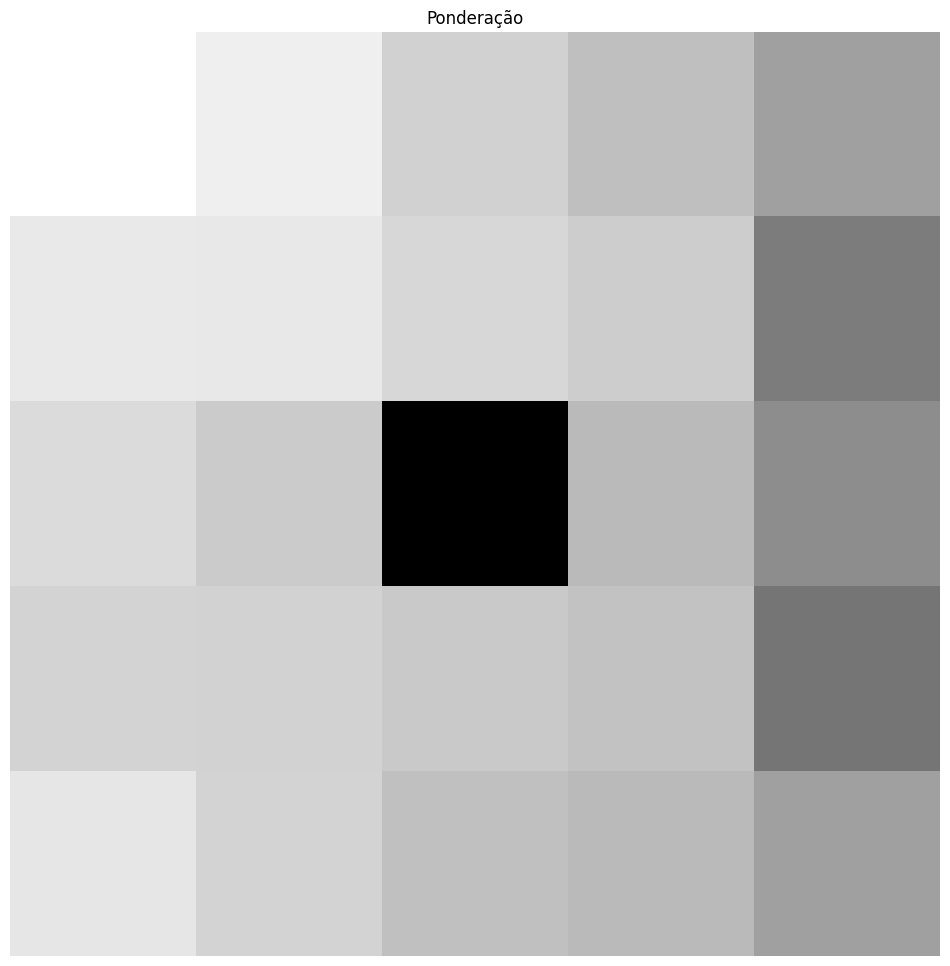

In [19]:
fig6, ax6 = gerar_imagem(
    {"ponder": {"desc": "Ponderação", "vetor": (0.29 * R) + (0.59) * (G) + (0.11 * B)}},
    figsize=(12, 12)
)
fig6.savefig(PROJECT_DIR / "assets" / "atv04-q06-03.png", dpi=400)

# Item C)

In [20]:
m = np.zeros((5, 5))
for i in range(5):
    for j in range(5):
        m[i, j] = (max(R[i, j], G[i, j], B[i, j]) + min(R[i, j], G[i, j], B[i, j])) / 2  # calculo de dessaturação

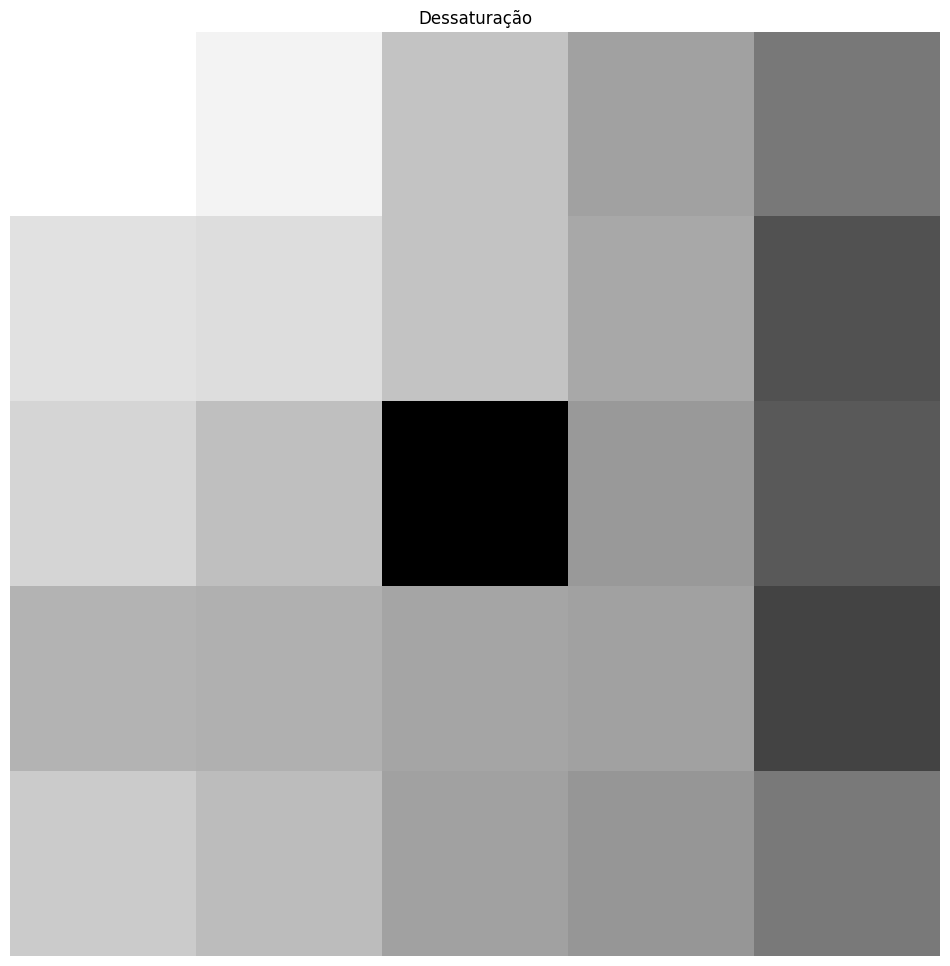

In [21]:
fig7, ax7 = gerar_imagem(
    {"dess": {"desc": "Dessaturação", "vetor": m}},
    figsize=(12, 12)
)
fig7.savefig(PROJECT_DIR / "assets" / "atv04-q06-04.png", dpi=400)

## Imagens geradas

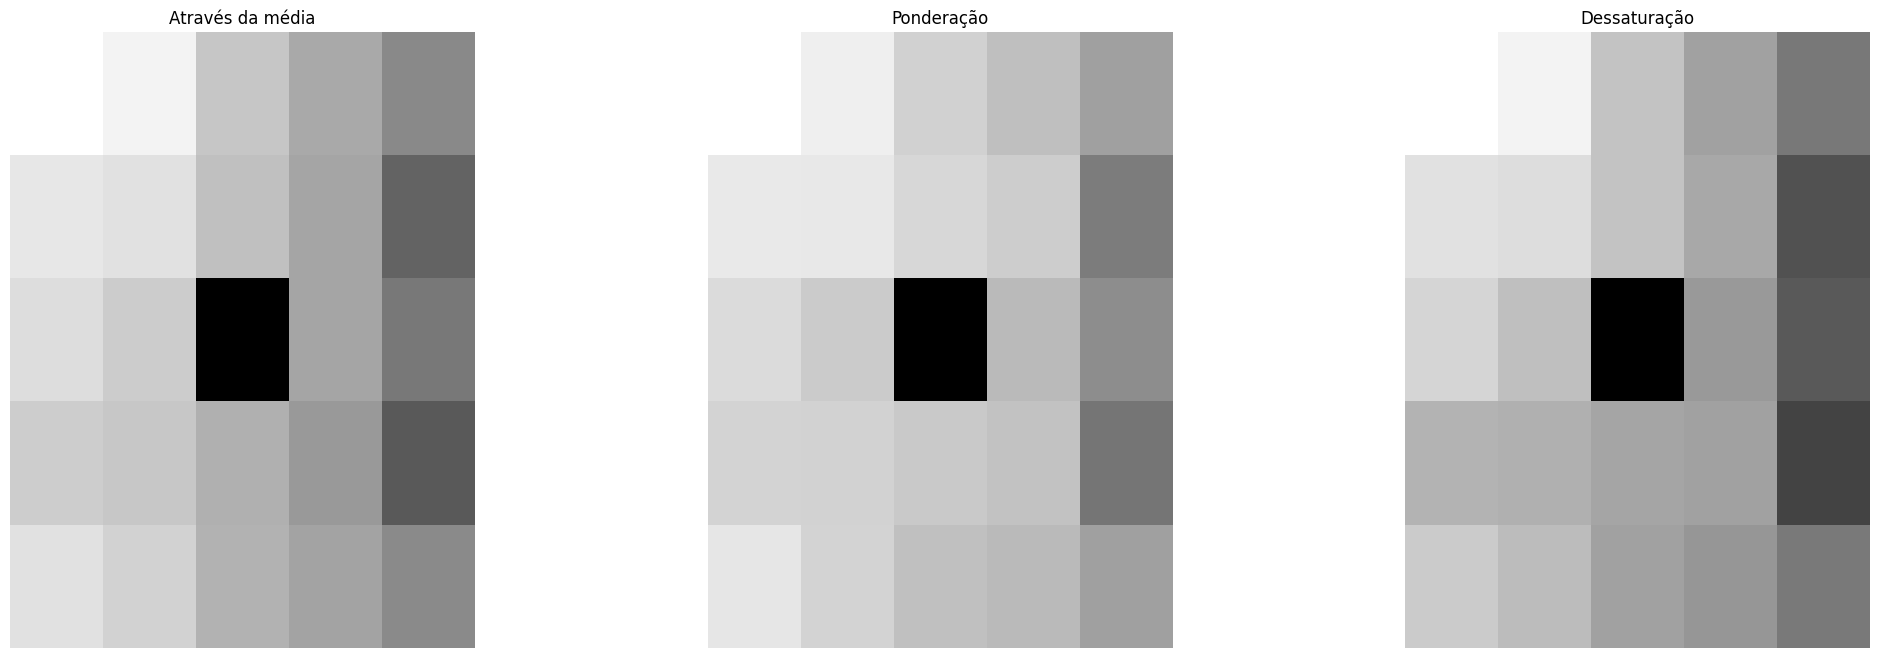

In [ ]:
fig8, ax8 = gerar_imagem(
    {
        "media": {"desc": "Através da média", "vetor": (R + G + B) / 3},
        "ponder": {"desc": "Ponderação", "vetor": (0.29 * R) + (0.59) * (G) + (0.11 * B)},
        "dess": {"desc": "Dessaturação", "vetor": m}
    },
    figsize=(24, 8)
)
fig8.savefig(PROJECT_DIR / "assets" / "atv04-q06-05.png", dpi=400)

# Questão 07

In [47]:
image = np.array([
    [120, 140, 120],
    [160, 180, 70]
], dtype=np.uint8)

binarized_image = floyd_steinberg_dithering(image)
print("Binarized Image:")
print(binarized_image)

old_pixel: 120.0
-- P(0, 0)
------------- ------------- P(0, 1) = 140.0+ 120.0 * 7/16 = 192.5
------------- ------------- P(1, 0) = 160.0 + 120.0 * 5/16 = 197.5
------------- ------------- P(1, 1) = 180.0 + 120.0 * 1/16 = 187.5
-- result: 
 [[  0.  192.5 120. ]
 [197.5 187.5  70. ]]

old_pixel: 192.5
-- P(0, 1)
------------- ------------- P(0, 2) = 120.0+ -62.5 * 7/16 = 92.65625
------------- ------------- P(1, 0) = 197.5 + -62.5 * 3/16 = 185.78125
------------- ------------- P(1, 1) = 187.5 + -62.5 * 5/16 = 167.96875
------------- ------------- P(1, 2) = 70.0 + -62.5 * 1/16 = 66.09375
-- result: 
 [[  0.      255.       92.65625]
 [185.78125 167.96875  66.09375]]

old_pixel: 92.65625
-- P(0, 2)
------------- ------------- P(1, 1) = 167.96875 + 92.65625 * 3/16 = 185.341796875
------------- ------------- P(1, 2) = 66.09375 + 92.65625 * 5/16 = 95.048828125
-- result: 
 [[  0.         255.           0.        ]
 [185.78125    185.34179688  95.04882812]]



old_pixel: 185.78125
-- P(1, 0)


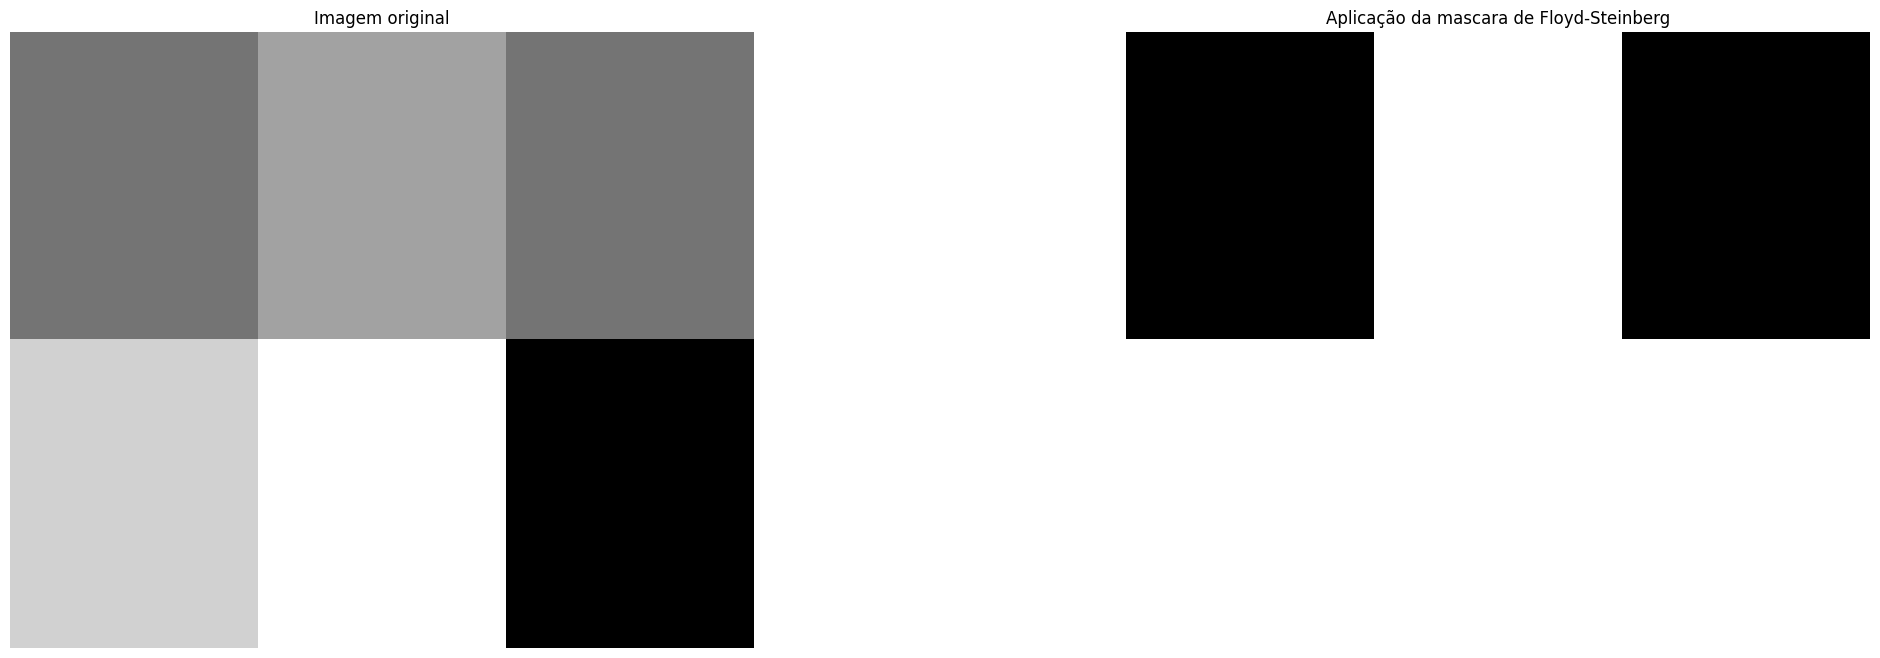

In [ ]:
fig9, ax9 = gerar_imagem(
    {
        "orig": {"desc": "Imagem original", "vetor": np.array(
            [
                [120, 140, 120],
                [160, 180, 70]
            ]
        )},
        "bina": {"desc": "Aplicação da mascara de Floyd-Steinberg", "vetor": np.array(
            [
                [0, 255, 0],
                [255, 255, 0]
            ]
        )}
    },
    figsize=(24, 8)
)
fig9.savefig(PROJECT_DIR / "assets" / "atv04-07-01.png", dpi=400)